In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../../data/raw/weatherHistory.csv")
print("Shape:", df.shape)
df.head()

Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [2]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [3]:
duplicates = df[df.duplicated()]
duplicates.shape

(24, 12)

In [4]:
df['Precip Type'] = df['Precip Type'].ffill() #ffill(), bfill(), mode() gives same values(assign to most rain)

In [5]:
df.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

In [6]:
df['Precip Type'].value_counts()

Precip Type
rain    85741
snow    10712
Name: count, dtype: int64

In [7]:
df['Summary'].value_counts()

Summary
Partly Cloudy                          31733
Mostly Cloudy                          28094
Overcast                               16597
Clear                                  10890
Foggy                                   7148
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Hu

In [8]:
df['Suitability'] = (df['Summary'] == 'Clear').astype(int)

In [9]:
df = df.drop_duplicates()

In [10]:
df = pd.get_dummies(
    df,
    columns=['Precip Type'],
    prefix='Precip',
    dtype=int
)

Handle Loud Cover

In [11]:
df['Loud Cover'].value_counts()

Loud Cover
0.0    96429
Name: count, dtype: int64

In [12]:
df = df.drop(columns=['Formatted Date', 'Summary', 'Daily Summary', 'Loud Cover'])

In [13]:
df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Suitability,Precip_rain,Precip_snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,1,0


In [14]:
df = df.rename(columns={
    'Temperature (C)': 'Temperature',
    'Apparent Temperature (C)': 'Apparent_Temperature',
    'Wind Speed (km/h)': 'Wind_Speed',
    'Wind Bearing (degrees)': 'Wind_Bearing',
    'Visibility (km)': 'Visibility',
    'Pressure (millibars)': 'Pressure',
    'Precip_rain': 'Precip_Rain',
    'Precip_snow': 'Precip_Snow'
})

Scaling the Dataset

In [15]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Temperature', 'Apparent_Temperature', 'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Pressure']
scaler = StandardScaler()
scaler.fit(df[num_cols])

StandardScaler()

In [16]:
df.head()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Suitability,Precip_Rain,Precip_Snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,1,0


In [17]:
from sklearn.model_selection import train_test_split
from sklearn. tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
X = df.drop(columns=['Suitability'])
y = df['Suitability']

pd_X = pd.DataFrame(X)
pd_y = pd.Series(y)

pd_X.head()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Precip_Rain,Precip_Snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,1,0


In [19]:
pd_y.head()

0    0
1    0
2    0
3    0
4    0
Name: Suitability, dtype: int64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(pd_X, pd_y, test_size=0.2, random_state=42)
print(f"Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}")

Training Samples: 77143, Testing Samples: 19286


In [23]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
print("\nTree Depth:", model_dt.get_depth())
print("Feature Importance:", pd.Series(model_dt. feature_importances_, index=X.columns))


Tree Depth: 40
Feature Importance: Temperature             0.105674
Apparent_Temperature    0.112465
Humidity                0.122121
Wind_Speed              0.154923
Wind_Bearing            0.144690
Visibility              0.134088
Pressure                0.224127
Precip_Rain             0.001187
Precip_Snow             0.000725
dtype: float64


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_dt = model_dt.predict(X_test)
print("\nDecision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt) :.2f}")
print(f"Precision: {precision_score(y_test, y_pred_dt) :.2f}")
print(f"Recall: {recall_score(y_test, y_pred_dt) :.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt) :.2f}")
print(f"ROC AUC: {roc_auc_score(y_test, model_dt.predict_proba(X_test)[:, 1]) :.2f}")


Decision Tree Metrics:
Accuracy: 0.85
Precision: 0.35
Recall: 0.37
F1 Score: 0.36
ROC AUC: 0.64


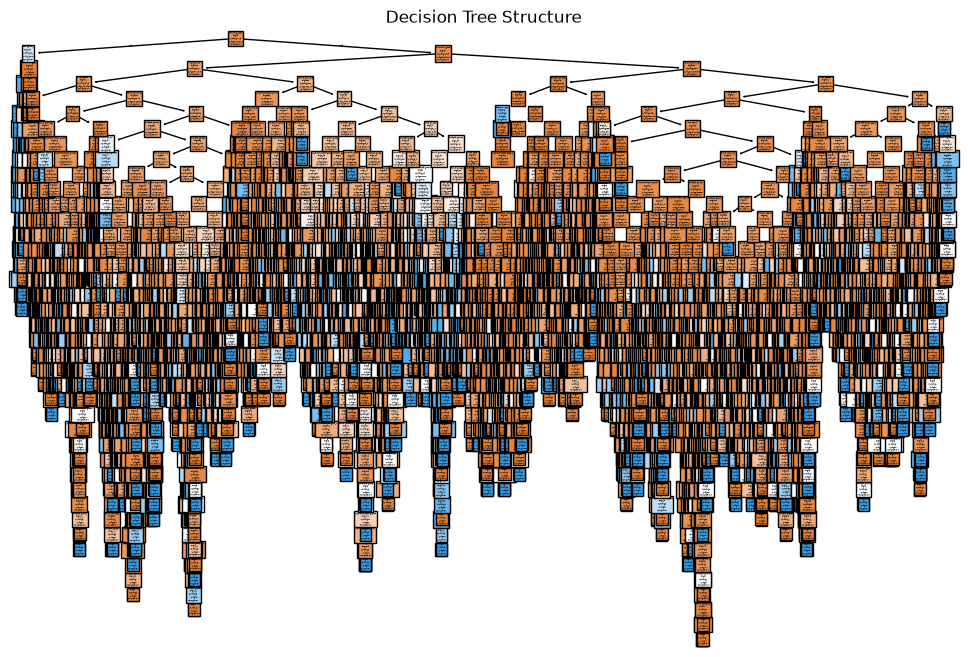

In [26]:
from sklearn. tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(model_dt, feature_names=X.columns,
        class_names=['malignant', 'benign'],
        filled=True)
plt.title("Decision Tree Structure")
plt.show()

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca. transform(X_test)

In [29]:
model_dt_pca = DecisionTreeClassifier(random_state=42).fit(X_train_pca, y_train)

In [30]:
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model_dt_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

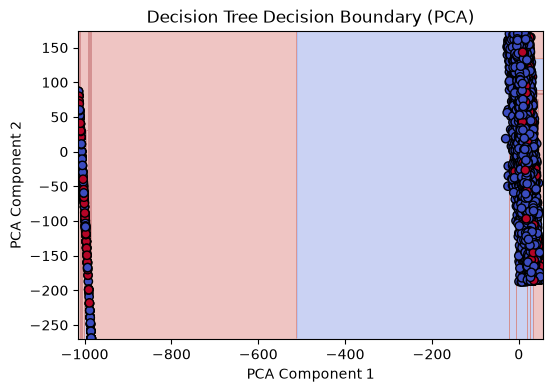

In [31]:
plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title("Decision Tree Decision Boundary (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

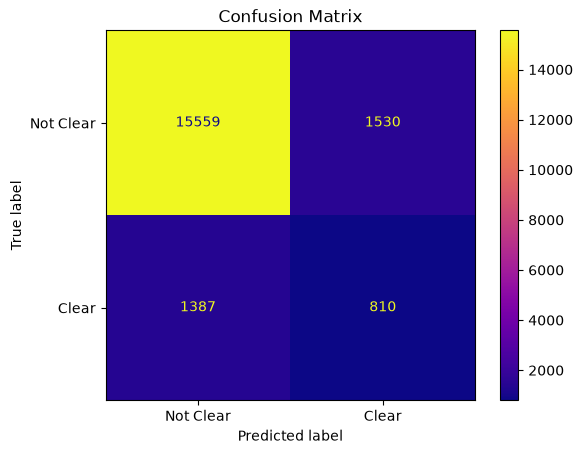

In [34]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Clear', 'Clear'])
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion Matrix")
plt.show()

In [39]:
for depth in [1, 3, 7, 10]:
    model_dt = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    y_pred_dt - model_dt.predict(X_test)
    print(f"Decision Tree (max_depth={depth}) Metrics:")
    print(f"Accuracy:{accuracy_score(y_test, y_pred_dt) :.2f},F1: {f1_score(y_test, y_pred_dt) :.2f}")

Decision Tree (max_depth=1) Metrics:
Accuracy:0.85,F1: 0.36
Decision Tree (max_depth=3) Metrics:
Accuracy:0.85,F1: 0.36
Decision Tree (max_depth=7) Metrics:
Accuracy:0.85,F1: 0.36
Decision Tree (max_depth=10) Metrics:
Accuracy:0.85,F1: 0.36
